# If necessary install the below packages (libraries) before loading them
Use install.packages in terminal rather than in the notebook.

`mamba activate r432
R
install.packages()`

In [2]:
# Downstream analysis using object created by Sara Grimm
# Match the R version and important package versions used in the original analysis
# R432

library(Seurat);       # v5.0.1  
library(ggplot2);      # v3.4.4
library(dplyr);
library(viridis);
library(dittoSeq);
library(scales);
library(scCustomize)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Warning message:
“package ‘viridisLite’ was built under R version 4.3.3”
Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


scCustomize v3.0.1
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



In [2]:
# Additional packages required for CellChat

library(CellChat);
library(patchwork);
options(stringsAsFactors=FALSE);
library(NMF);
library(ggalluvial);
library(ComplexHeatmap);
library(wordcloud);

Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

Warning message:
“package ‘cluster’ was built under R version 4.3.3”
NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘NMF’


The following objects are masked from ‘package:igraph’:

    algorithm, compare


Loading required package: grid

ComplexHeatmap version 2.21.2
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHea

In [185]:
# Record active package versions
packageVersion("Seurat");
packageVersion("ggplot2");        
packageVersion("dplyr");
packageVersion("viridis");
packageVersion("dittoSeq");
packageVersion("CellChat");
packageVersion("patchwork");
packageVersion("NMF");
packageVersion("ggalluvial");
packageVersion("ComplexHeatmap");
packageVersion("wordcloud");
packageVersion("scales");
packageVersion("scCustomize");

[1] ‘5.0.1’

[1] ‘3.4.4’

[1] ‘1.1.4’

[1] ‘0.6.5’

[1] ‘1.14.3’

...

[1] ‘0.12.5’

[1] ‘2.21.2’

[1] ‘2.6’

[1] ‘1.3.0’

[1] ‘3.0.1’

In [11]:
# Read in the processed RDS file from Sara Grimm, which holds a seurat object with filtered, integrated, annotated cells from 4 samples.
Adult_Srfflox_SrfKO <- readRDS("/ddn/gs1/home/marquardtrm/PRcreSRF_scRNAseq_Sara/data_rds/RM-adult_SrfKO-FilteredIntegratedAnnotated.14mar2025.rds")
Adult_Srfflox_SrfKO
head(Adult_Srfflox_SrfKO)

An object of class Seurat 
26486 features across 33500 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

,orig.ident,nCount_RNA,nFeature_RNA,Sample,genotype,batch,percent.mt,percent.rp,percent.hg,S.Score,G2M.Score,Phase,old.ident,CC.Difference,broad_cluster,CellType,CellSubtype,CellTypeBroad
,<chr>,<dbl>,<int>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
Ctrl1___AAACCCAAGACCATAA-1,Ctrl1,13853,4097,Ctrl1,Ctrl,1,4.858153,21.86530,0,-0.115882733,-0.10197415,G1,Ctrl1,-0.01390858,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCAAGGTCCCGT-1,Ctrl1,5652,2163,Ctrl1,Ctrl,1,2.813163,11.34112,0,-0.087413046,-0.16113772,G1,Ctrl1,0.07372467,5,Macrophage,Macrophage,Immune
Ctrl1___AAACCCACATCACCAA-1,Ctrl1,6085,2336,Ctrl1,Ctrl,1,2.678718,10.56697,0,-0.070066492,-0.04961594,G1,Ctrl1,-0.02045055,15,gammadeltaT,gammadeltaT,Immune
Ctrl1___AAACCCACATCTAACG-1,Ctrl1,12378,3609,Ctrl1,Ctrl,1,3.869769,14.76006,0,-0.035871272,-0.09095433,G1,Ctrl1,0.05508306,11,SmoothMuscle,none,SmoothMuscle
Ctrl1___AAACCCACATGTCAGT-1,Ctrl1,15094,4189,Ctrl1,Ctrl,1,3.186697,23.22777,0,0.795792256,0.30071105,S,Ctrl1,0.49508121,10,ProliferatingNK,ProliferatingNK,Immune
Ctrl1___AAACCCAGTAATGTGA-1,Ctrl1,14440,4595,Ctrl1,Ctrl,1,4.903047,18.98199,0,0.056406385,0.58059310,G2M,Ctrl1,-0.52418671,7,ProliferatingFibroblastG2M,ProliferatingFibroblastG2M,Fibroblast
Ctrl1___AAACCCAGTGTAGGAC-1,Ctrl1,19929,4617,Ctrl1,Ctrl,1,5.996287,24.48191,0,-0.084860322,-0.12601747,G1,Ctrl1,0.04115715,3,GlandularEpithelial,GlandularEpithelial,Epithelial
Ctrl1___AAACCCATCGCCGAGT-1,Ctrl1,20720,5042,Ctrl1,Ctrl,1,4.917954,23.61004,0,-0.007086613,-0.04976484,G1,Ctrl1,0.04267823,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCATCGGCAGTC-1,Ctrl1,15461,4527,Ctrl1,Ctrl,1,4.359356,15.99508,0,0.559701893,0.82661813,G2M,Ctrl1,-0.26691623,2,Endothelial,none,Endothelial


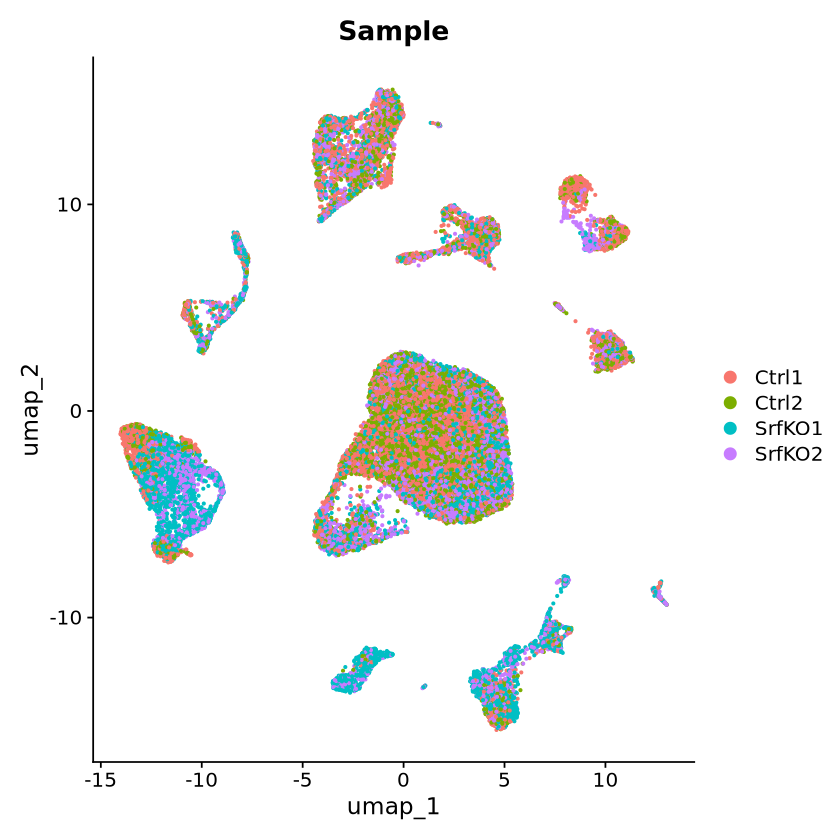

In [15]:
DimPlot(Adult_Srfflox_SrfKO, group.by="Sample", pt.size=0.5, reduction='umap', shuffle=TRUE);

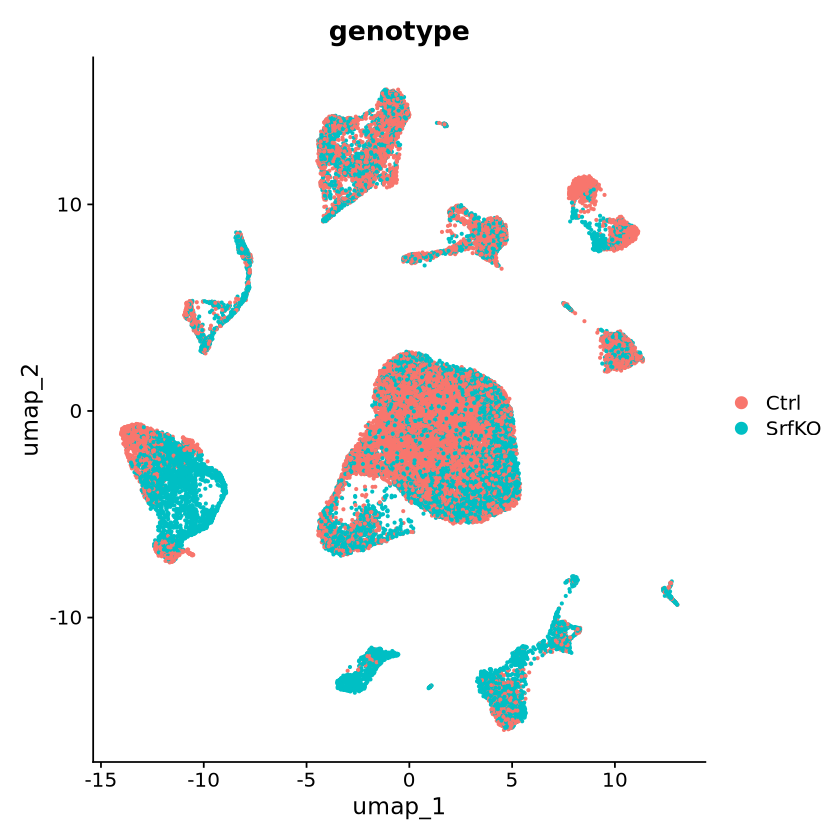

In [13]:
DimPlot(Adult_Srfflox_SrfKO, group.by="genotype", pt.size=0.5, reduction='umap', shuffle=TRUE);

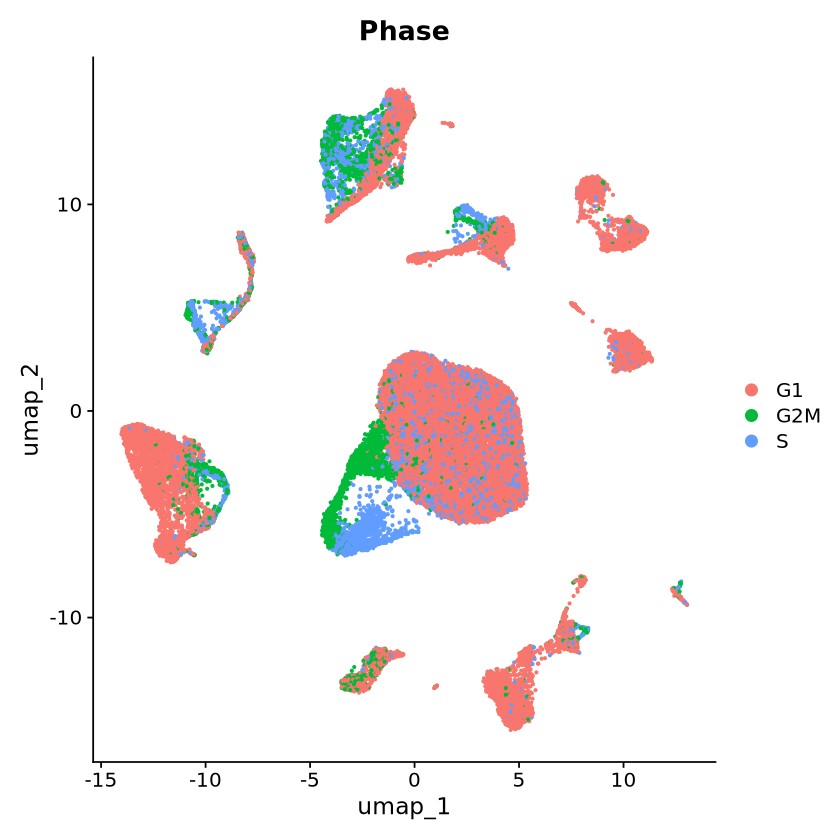

In [14]:
DimPlot(Adult_Srfflox_SrfKO, group.by="Phase", pt.size=0.5, reduction='umap', shuffle=TRUE)

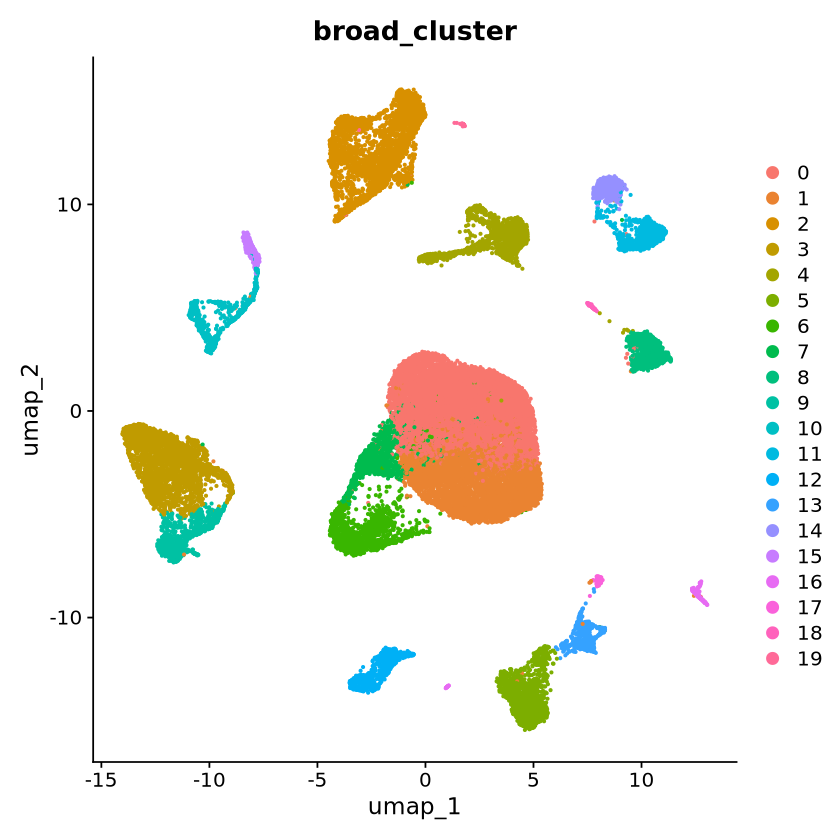

In [30]:
DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE)

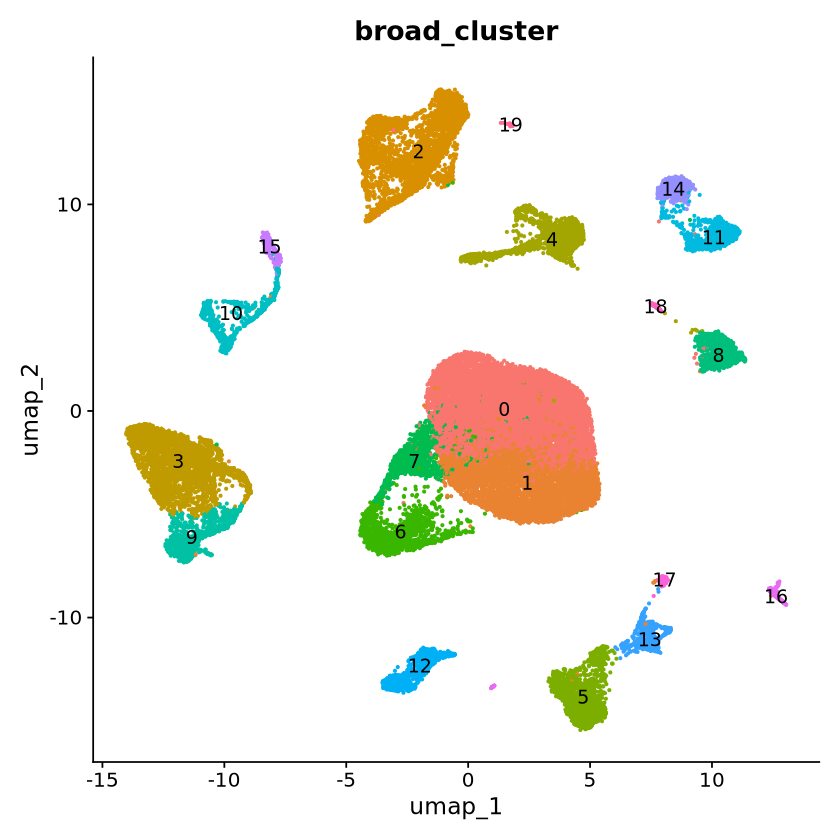

In [34]:
DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE
       )+NoLegend();

In [50]:
png(file = "PlotByCluster.png",
    width = 16, height = 16, units = "cm", res = 600)

DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE
       )+NoLegend()

dev.off()

pdf 
  2

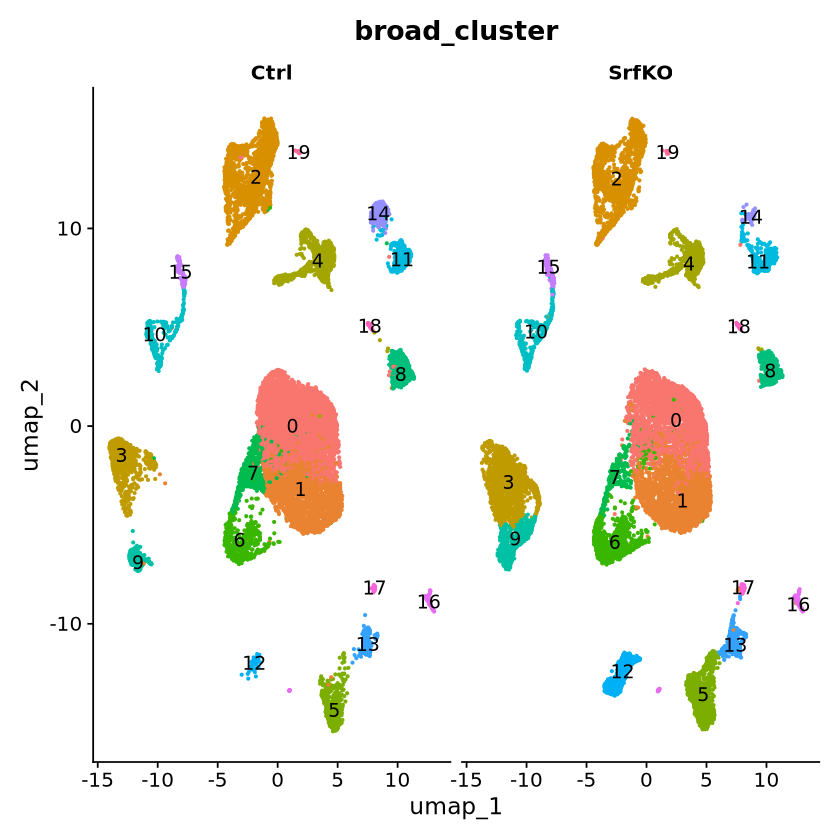

In [51]:
DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE, split.by="genotype"
       )+NoLegend()

In [57]:
png(file = "PlotByCluster_SplitByGenotype.png",
    width = 29, height = 16, units = "cm", res = 600)

DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE, split.by="genotype"
        ) +NoLegend()

dev.off()

pdf 
  2

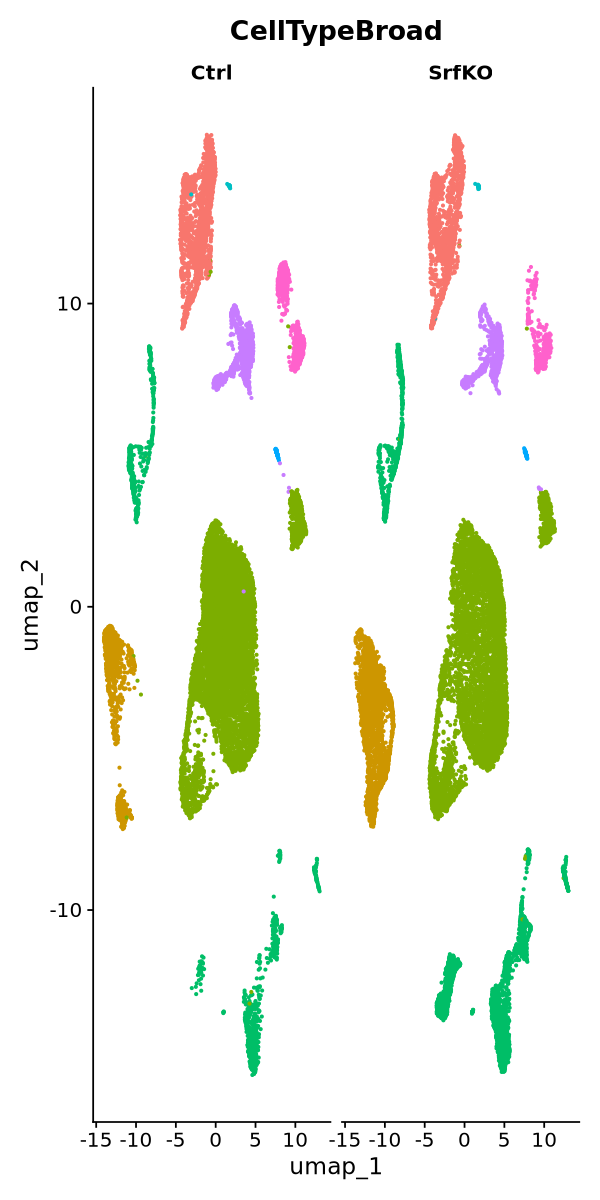

In [155]:
DimPlot(Adult_Srfflox_SrfKO, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
       )+NoLegend()

In [156]:
png(file = "PlotByBroadCellType_SplitByGenotype.png",
    width = 29, height = 16, units = "cm", res = 600)

DimPlot(Adult_Srfflox_SrfKO, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
        )

dev.off()

pdf 
  2

In [157]:
png(file = "PlotByBroadCellType_SplitByGenotype_nolegend.png",
    width = 29, height = 16, units = "cm", res = 600)

DimPlot(Adult_Srfflox_SrfKO, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
        )+NoLegend()

dev.off()

pdf 
  2

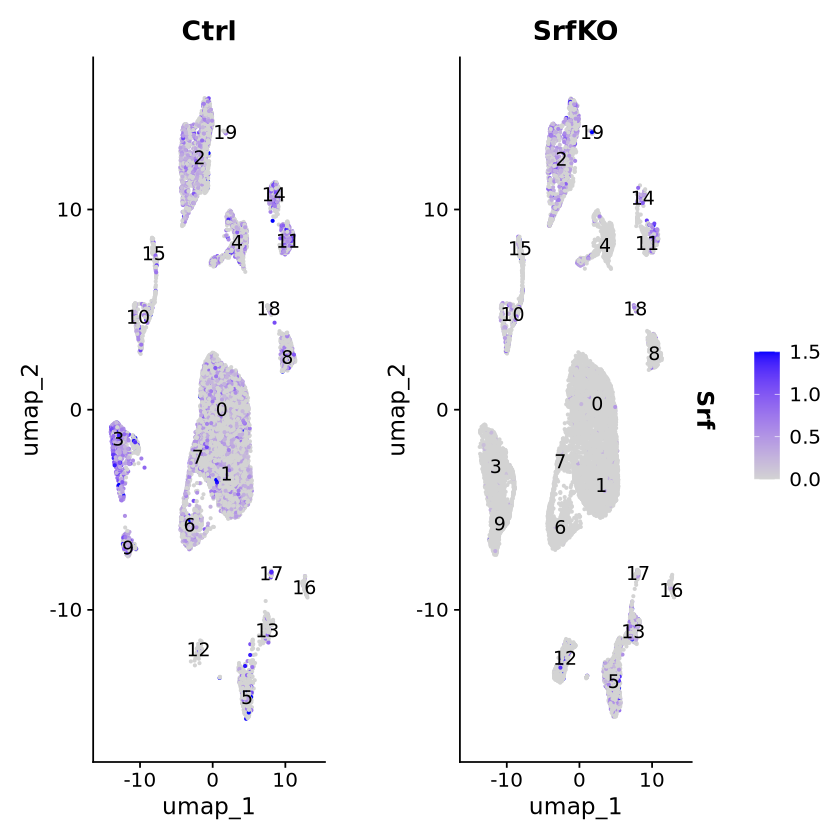

In [62]:
Idents(Adult_Srfflox_SrfKO) <- Adult_Srfflox_SrfKO$broad_cluster

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=TRUE, 
            split.by="genotype",
            max.cutoff = 1.5,
            ) + theme(legend.position = "right")

In [64]:
png(file = "PlotSrf_SplitByGenotype_nomax.png",
    width = 29, height = 16, units = "cm", res = 600)

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=TRUE, 
            split.by="genotype",
            ) + theme(legend.position = "right")

dev.off()

pdf 
  2

In [65]:
png(file = "PlotSrf_SplitByGenotype_max1-5.png",
    width = 29, height = 16, units = "cm", res = 600)

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=TRUE, 
            split.by="genotype",
            max.cutoff = 1.5,
            ) + theme(legend.position = "right")

dev.off()

pdf 
  2

In [68]:
png(file = "PlotSrf_SplitByGenotype_max1-5_nolegend.png",
    width = 33, height = 16, units = "cm", res = 600)

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=TRUE, 
            split.by="genotype",
            max.cutoff = 1.5,
            )

dev.off()

pdf 
  2

In [161]:
png(file = "PlotSrf_SplitByGenotype_max1-5_nolegend_nolabel.png",
    width = 33, height = 16, units = "cm", res = 600)

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=FALSE, 
            split.by="genotype",
            max.cutoff = 1.5,
            )

dev.off()

pdf 
  2

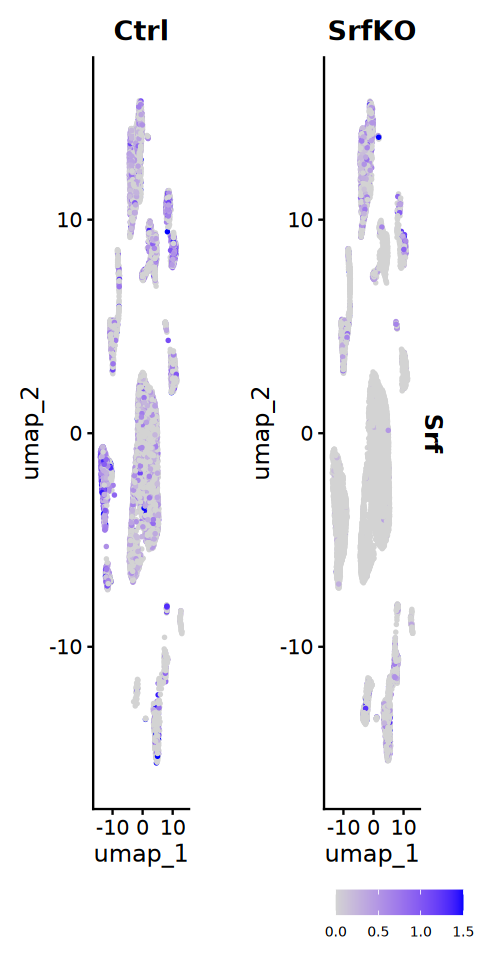

In [330]:
FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=FALSE, 
            split.by="genotype",
            max.cutoff = 1.5,
            ) + theme(legend.position = "bottom", legend.text = element_text(angle = 0, size = 8))

In [331]:
png(file = "PlotSrf_SplitByGenotype_max1-5_nolegend_nolabel_turnscale.png",
    width = 33, height = 16, units = "cm", res = 600)

FeaturePlot(Adult_Srfflox_SrfKO, features = c('Srf'), 
            pt.size=0.5,
            label=FALSE, 
            split.by="genotype",
            max.cutoff = 1.5,
            ) + theme(legend.position = "bottom", legend.text = element_text(angle = 0, size = 8))

dev.off()

pdf 
  2

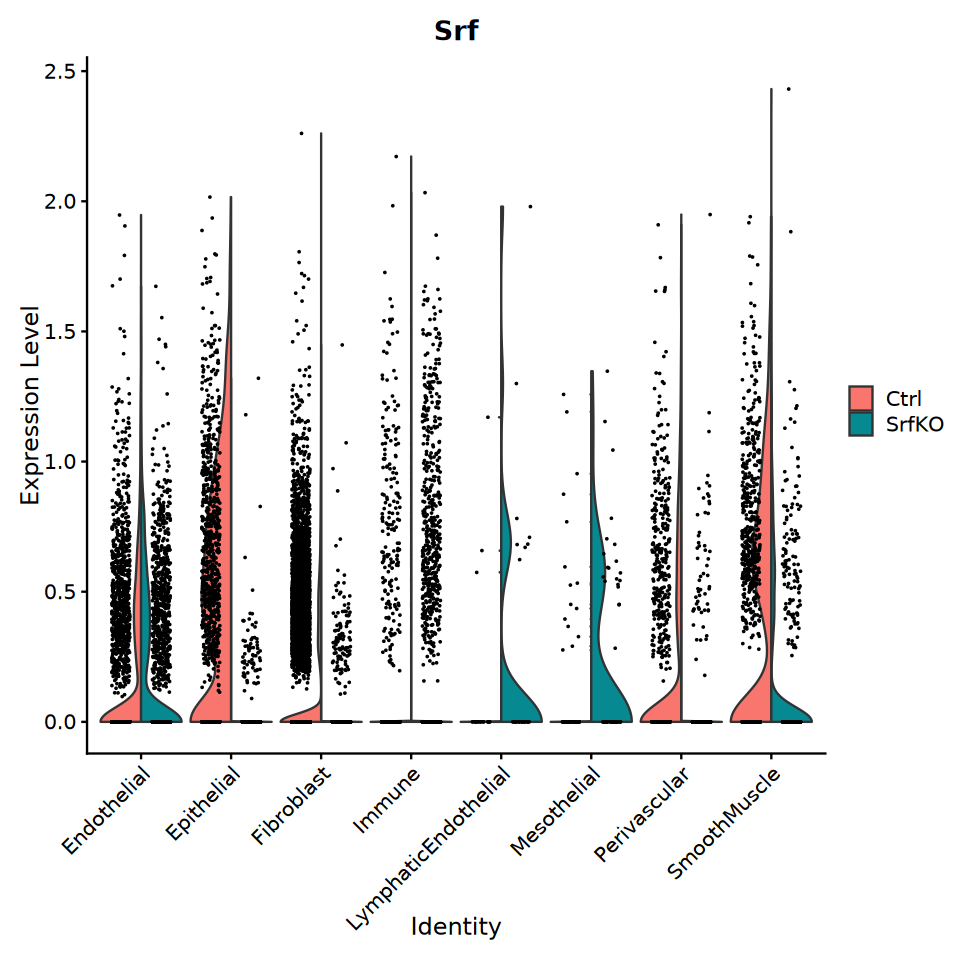

In [195]:
# Violin Plot Srf by broad cell type

saved <- options(repr.plot.width = 8, repr.plot.height = 8) # Make the plots bigger from here on out, save old options
VlnPlot(Adult_Srfflox_SrfKO_tmp, features = c("Srf"), 
        group.by = "CellTypeBroad",
        split.by = "genotype",
        split.plot = TRUE,
        pt.size = 0.001,
        ncol = 1)
options(saved) # restore old settings

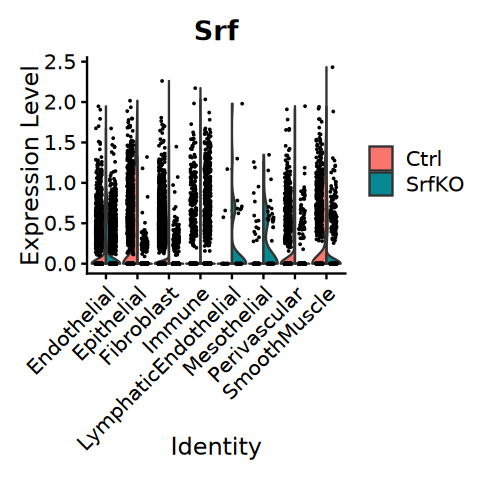

In [199]:
# Violin Plot Srf by broad cell type (smaller)

saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
VlnPlot(Adult_Srfflox_SrfKO_tmp, features = c("Srf"), 
        group.by = "CellTypeBroad",
        split.by = "genotype",
        split.plot = TRUE,
        pt.size = 0.01,
        ncol = 1)
options(saved) # restore old settings

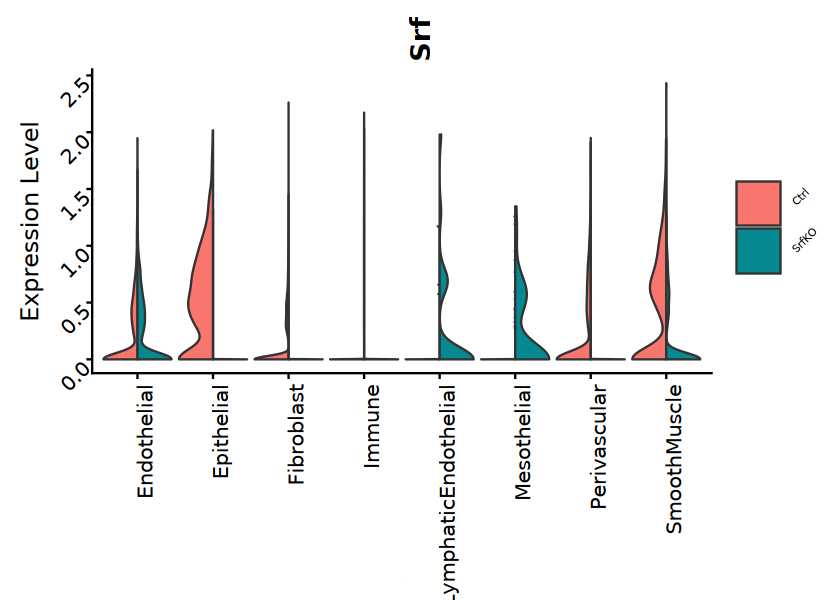

In [333]:
# Violin Plot Srf by broad cell type (turn)

saved <- options(repr.plot.width = 7, repr.plot.height = 5) # Make the plots bigger from here on out, save old options

VlnPlot(Adult_Srfflox_SrfKO_tmp, features = c("Srf"), 
        group.by = "CellTypeBroad",
        split.by = "genotype",
        split.plot = TRUE,
        pt.size = 0,
        ncol = 1) + theme(axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
                          axis.text.y = element_text(angle = 45, vjust = 1, hjust=1),
                          axis.title.x = element_text(size = 0),
                          legend.text = element_text(angle = 45, size = 6),
                          legend.key.size = unit(1, "cm") ,
                          plot.title = element_text(angle = 90, hjust = 0.5, vjust = 0.5),
                          plot.title.position = "plot",
                          #aspect.ratio = 1/3
                          )

options(saved) # restore old settings

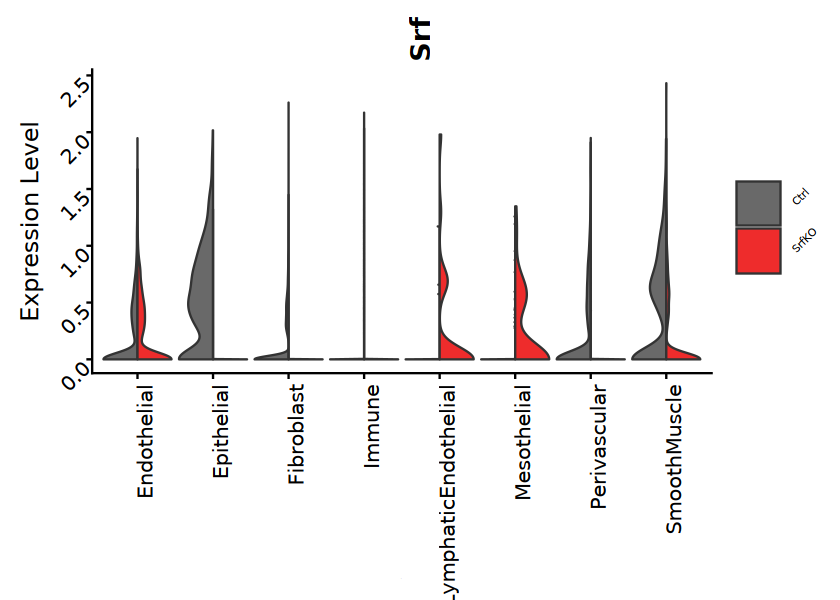

In [352]:
# Violin Plot Srf by broad cell type (turn), update colors

saved <- options(repr.plot.width = 7, repr.plot.height = 5) # Make the plots bigger from here on out, save old options

VlnPlot(Adult_Srfflox_SrfKO_tmp, features = c("Srf"), 
        group.by = "CellTypeBroad",
        split.by = "genotype",
        split.plot = TRUE,
        cols = c("dimgrey", "firebrick2"),
        pt.size = 0,
        ncol = 1) + theme(axis.text.x = element_text(angle = 90, vjust = 1, hjust=1),
                          axis.text.y = element_text(angle = 45, vjust = 1, hjust=1),
                          axis.title.x = element_text(size = 0),
                          legend.text = element_text(angle = 45, size = 6),
                          legend.key.size = unit(1, "cm") ,
                          plot.title = element_text(angle = 90, hjust = 0.5, vjust = 0.5),
                          plot.title.position = "plot",
                          #aspect.ratio = 1/3
                          )

options(saved) # restore old settings

Picking joint bandwidth of 0.0276



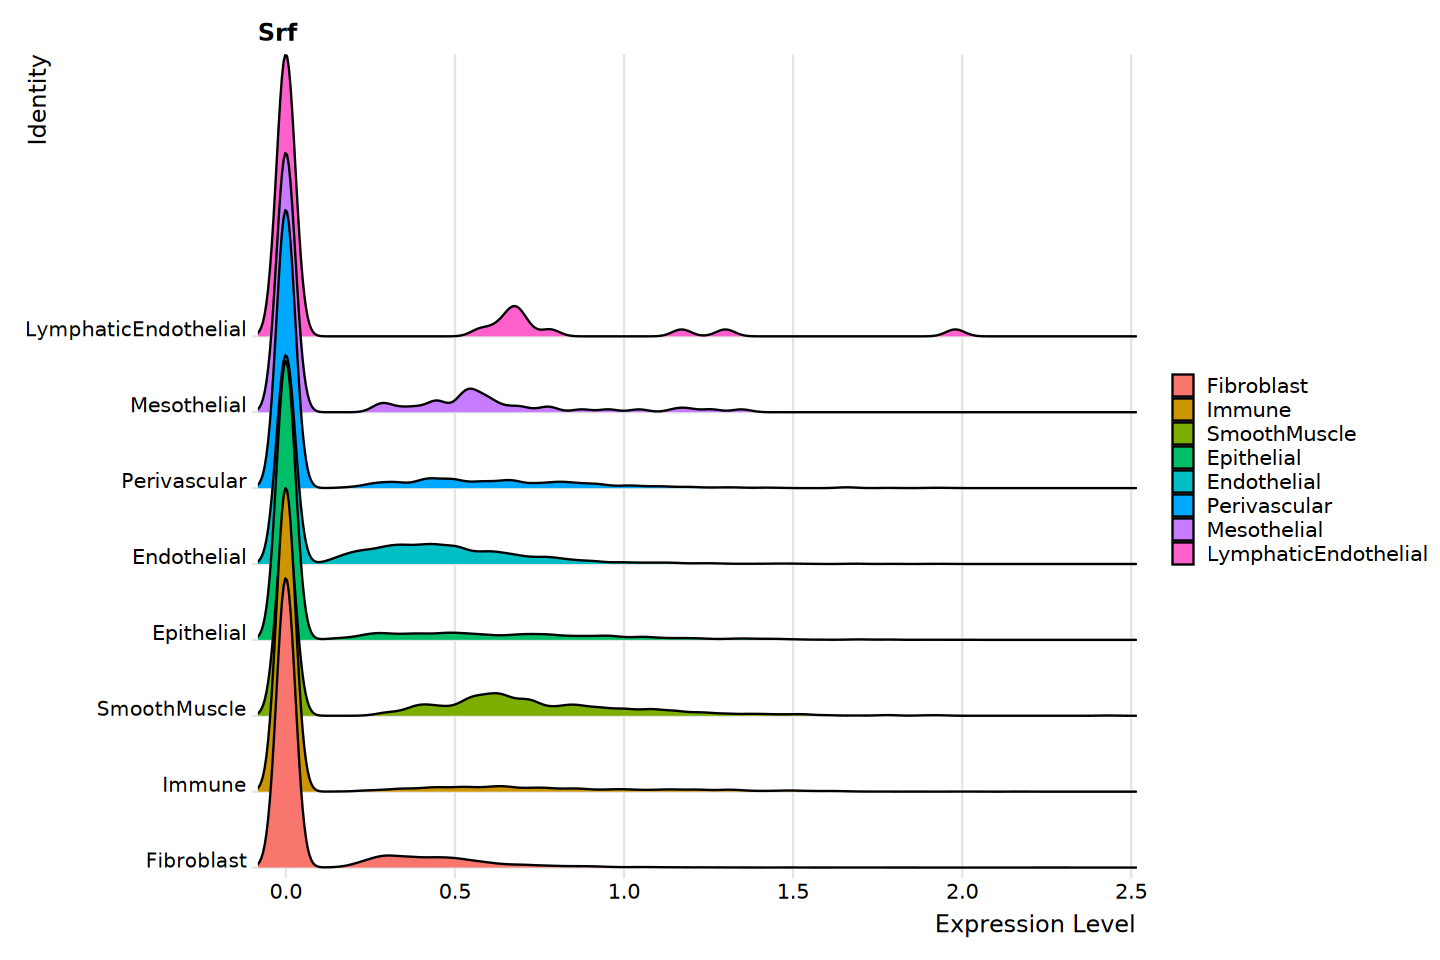

In [215]:
# Ridge Plot Srf by broad cell type

saved <- options(repr.plot.width = 12, repr.plot.height = 8) # Make the plots bigger from here on out, save old options
RidgePlot(Adult_Srfflox_SrfKO_tmp, features = c("Srf"),
           #group.by = "genotype",
)
options(saved) # restore old settings

In [216]:
?VlnPlot

In [194]:
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_tmp, features = "Srf", threshold = 0)
percent_stats

,Fibroblast,Immune,SmoothMuscle,Epithelial,Endothelial,Perivascular,Mesothelial,LymphaticEndothelial
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Srf,19.17233,15.14501,43.90956,22.02597,41.68975,22.29263,27.55906,21.15385


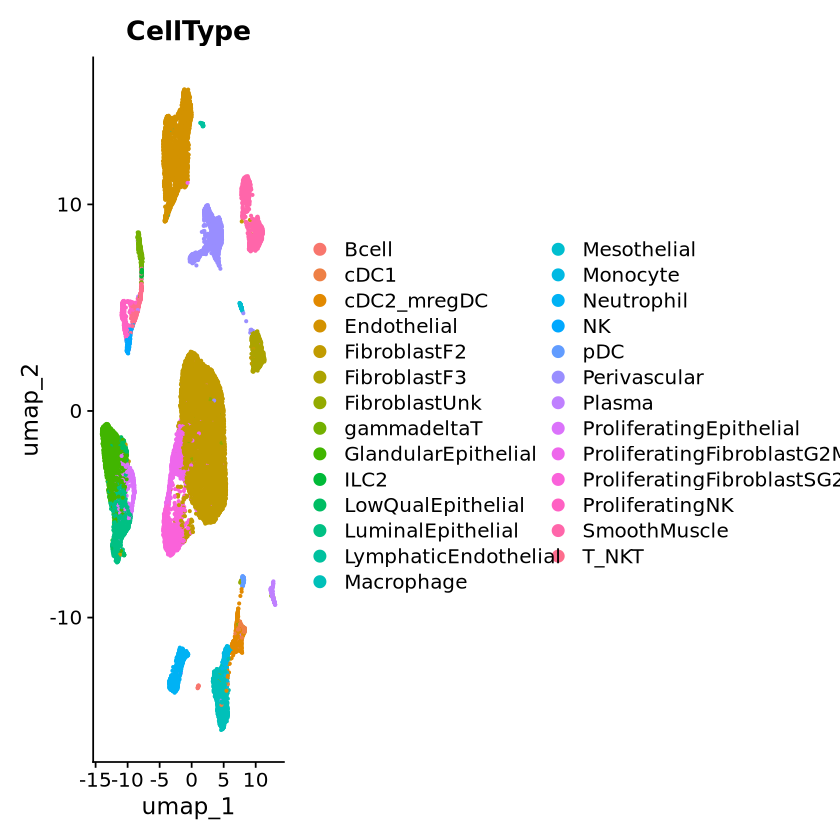

In [25]:
DimPlot(Adult_Srfflox_SrfKO, group.by="CellType", pt.size=0.5, reduction='umap', shuffle=TRUE)

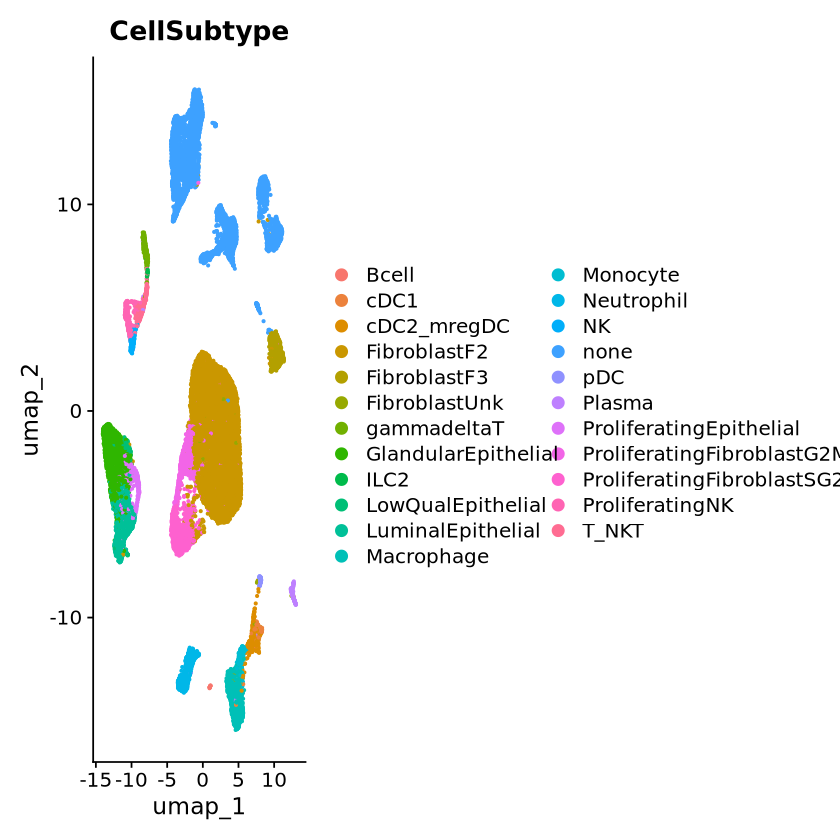

In [18]:
DimPlot(Adult_Srfflox_SrfKO, group.by="CellSubtype", pt.size=0.5, reduction='umap', shuffle=TRUE) 

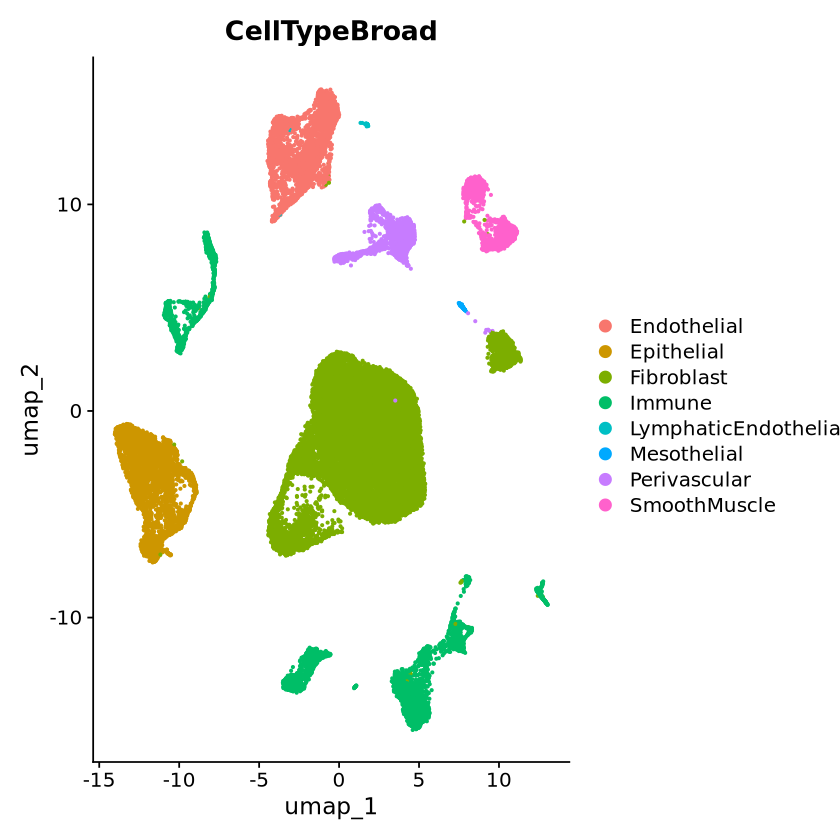

In [19]:
DimPlot(Adult_Srfflox_SrfKO, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE) 

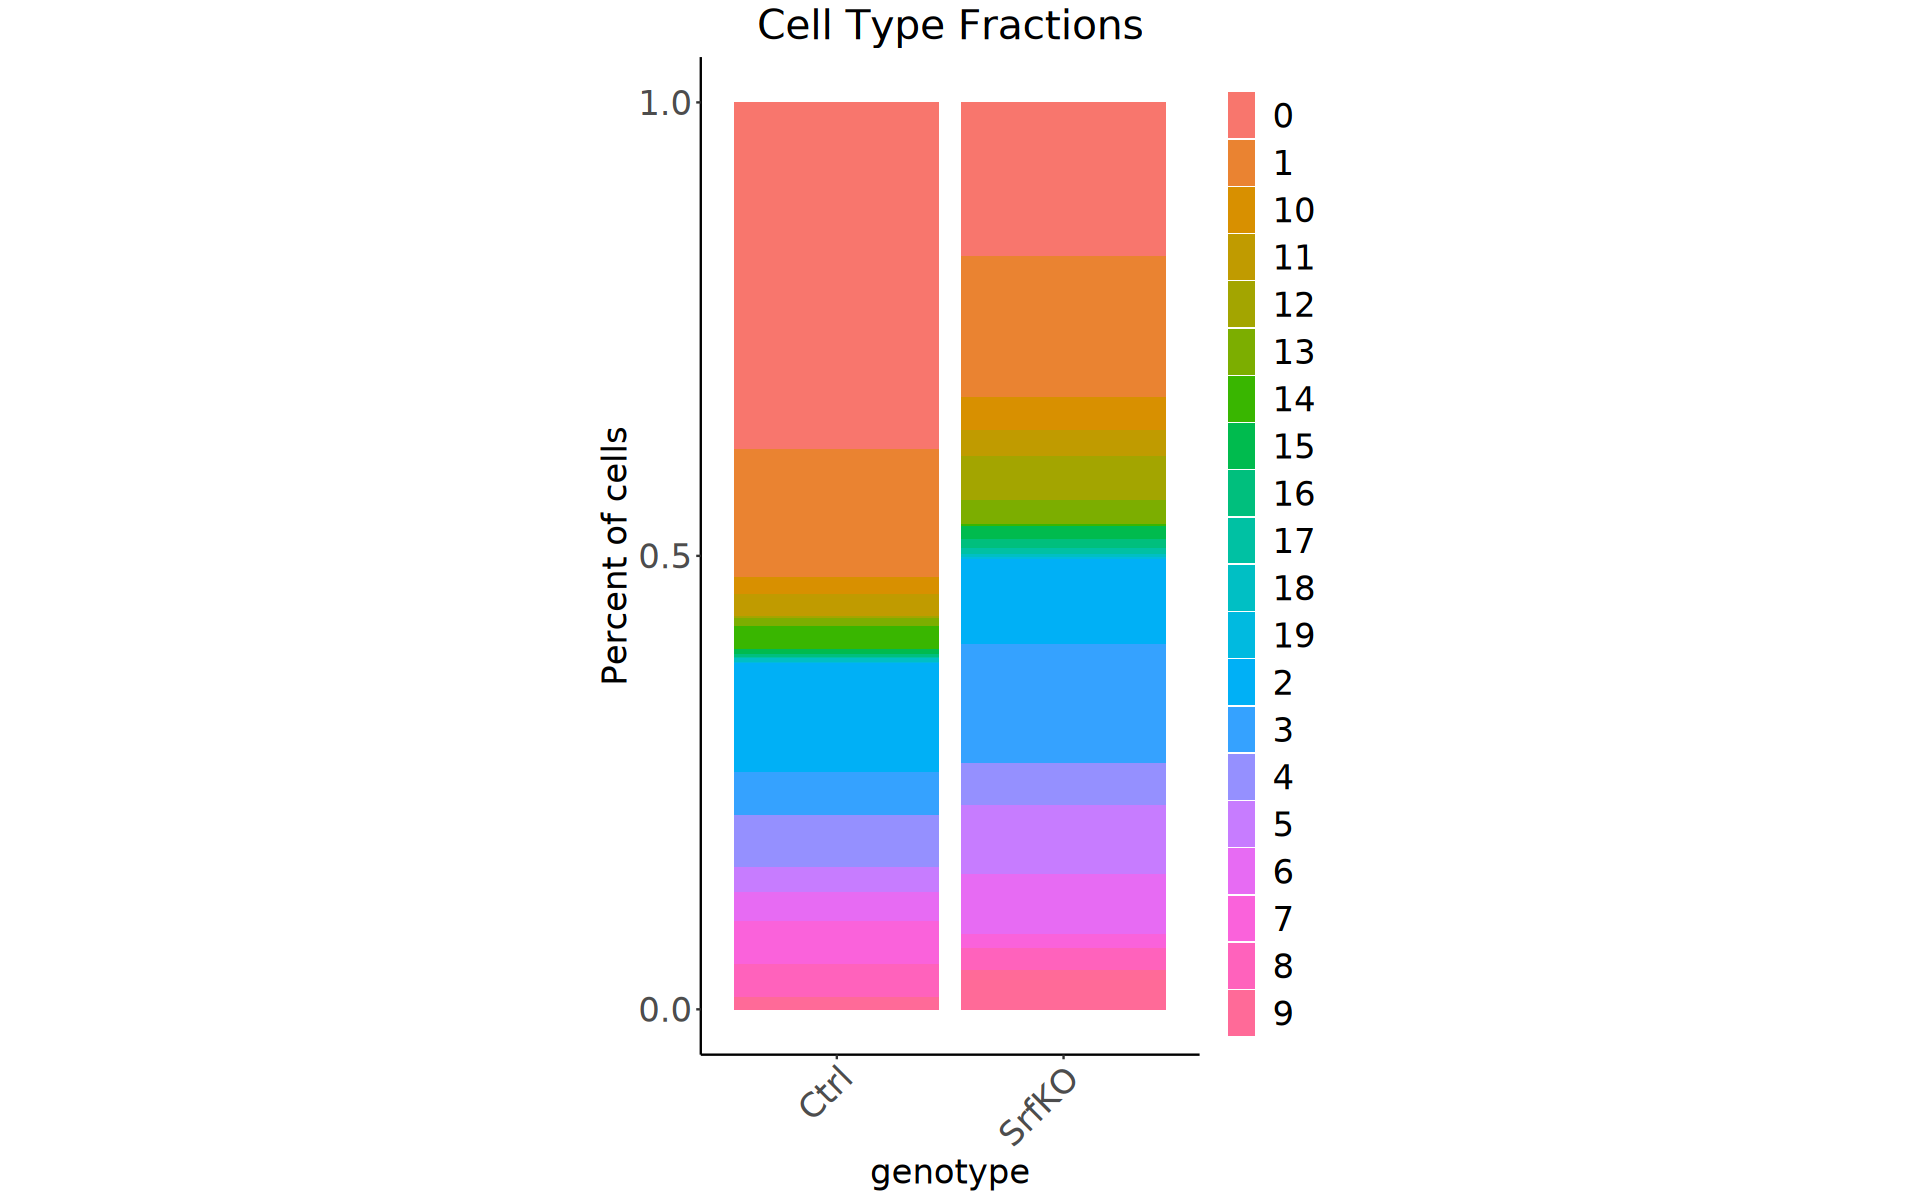

In [242]:
# Use DittoSeq to plot fraction of each cluster by genotype

# first some prep work to extract the color pallette from the seurat object
require(scales)
Adult_Srfflox_SrfKO_tmp <- Adult_Srfflox_SrfKO
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$broad_cluster
# Create vector with levels of object@ident
identities <- levels(Adult_Srfflox_SrfKO_tmp)
# Create vector of default ggplot2 colors
my_color_palette <- hue_pal()(length(identities))
# Use dittoBarPlot to generate the plot with some customization

saved <- options(repr.plot.width = 16, repr.plot.height = 10) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "broad_cluster", 
             group.by = "genotype", 
             color.panel = my_color_palette, 
             main = "Cell Type Fractions") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 2/1)

options(saved) # restore old settings

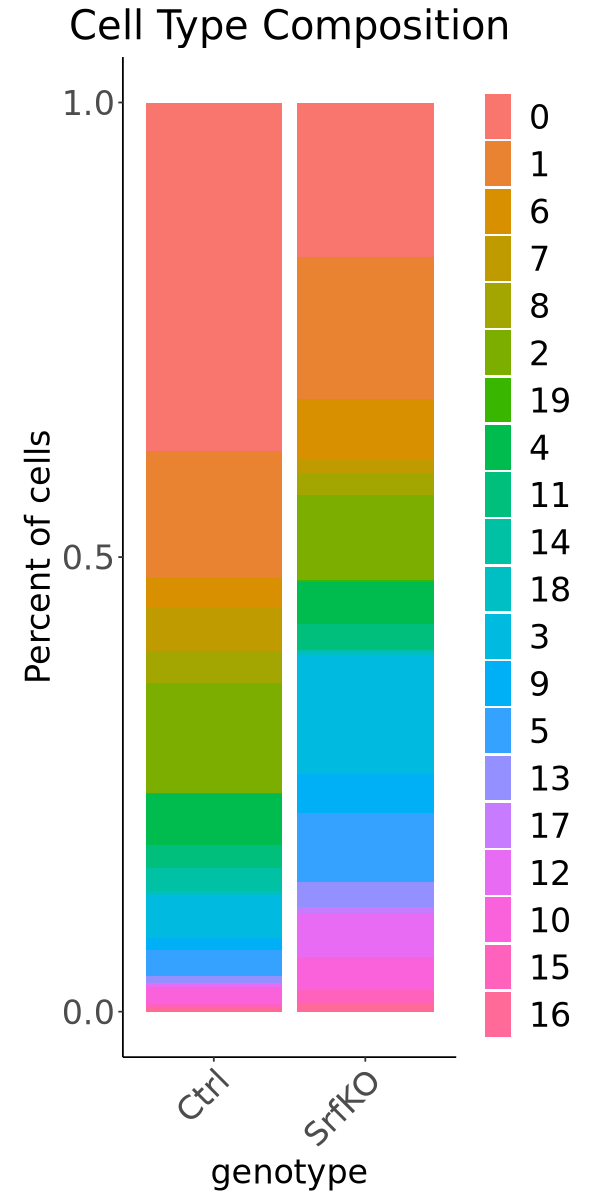

In [133]:
# Change order
# Use DittoSeq to plot fraction of each cluster by genotype

# first some prep work to extract the color pallette from the seurat object
require(scales)
Adult_Srfflox_SrfKO_tmp <- Adult_Srfflox_SrfKO
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$broad_cluster
# Create vector with levels of object@ident
identities <- levels(Adult_Srfflox_SrfKO_tmp)
# Create vector of default ggplot2 colors
my_color_palette <- hue_pal()(length(identities))
# Use dittoBarPlot to generate the plot with some customization

saved <- options(repr.plot.width = 5, repr.plot.height = 10) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "broad_cluster", 
             group.by = "genotype", 
             color.panel = my_color_palette, 
             var.labels.reorder = c(1, 2, 17, 18, 19, 13, 12, 15, 4, 7, 11, 14, 20, 16, 6, 10, 5, 3, 8, 9),
             main = "Cell Type Composition") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 3/1)

options(saved) # restore old settings

In [126]:
# Count cells by type to compare between genotypes
cell_table <- table(Adult_Srfflox_SrfKO_tmp$broad_cluster, Adult_Srfflox_SrfKO_tmp$genotype)
cell_table

    
     Ctrl SrfKO
  0  6742  2693
  1  2470  2484
  2  2118  1492
  3   845  2083
  4  1001   735
  5   489  1206
  6   568  1054
  7   830   249
  8   633   376
  9   235   687
  10  332   577
  11  442   455
  12   39   766
  13  152   430
  14  441    33
  15   88   220
  16   67   155
  17   21   113
  18   67    60
  19   21    31

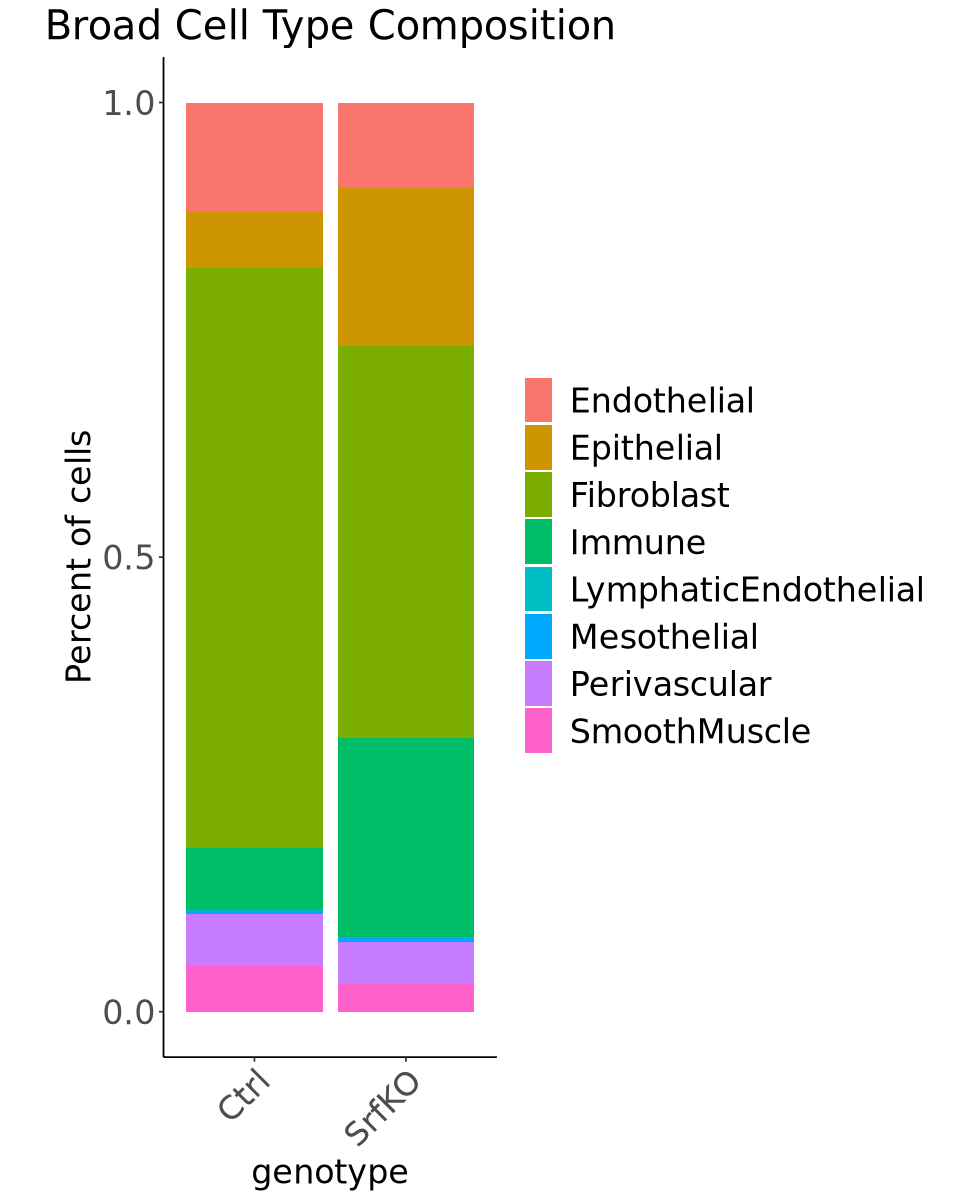

In [153]:
# Use DittoSeq to plot fraction of each broad cell type by genotype

# first some prep work to extract the color pallette from the seurat object
require(scales)
Adult_Srfflox_SrfKO_tmp <- Adult_Srfflox_SrfKO
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$CellTypeBroad
# Create vector with levels of object@ident
identities <- levels(Adult_Srfflox_SrfKO_tmp)
# Create vector of default ggplot2 colors
my_color_palette <- hue_pal()(length(identities))
# Use dittoBarPlot to generate the plot with some customization

saved <- options(repr.plot.width = 8, repr.plot.height = 10) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "CellTypeBroad", 
             group.by = "genotype",
             color.panel = my_color_palette, 
             main = "Broad Cell Type Composition") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 3/1)

options(saved) # restore old settings

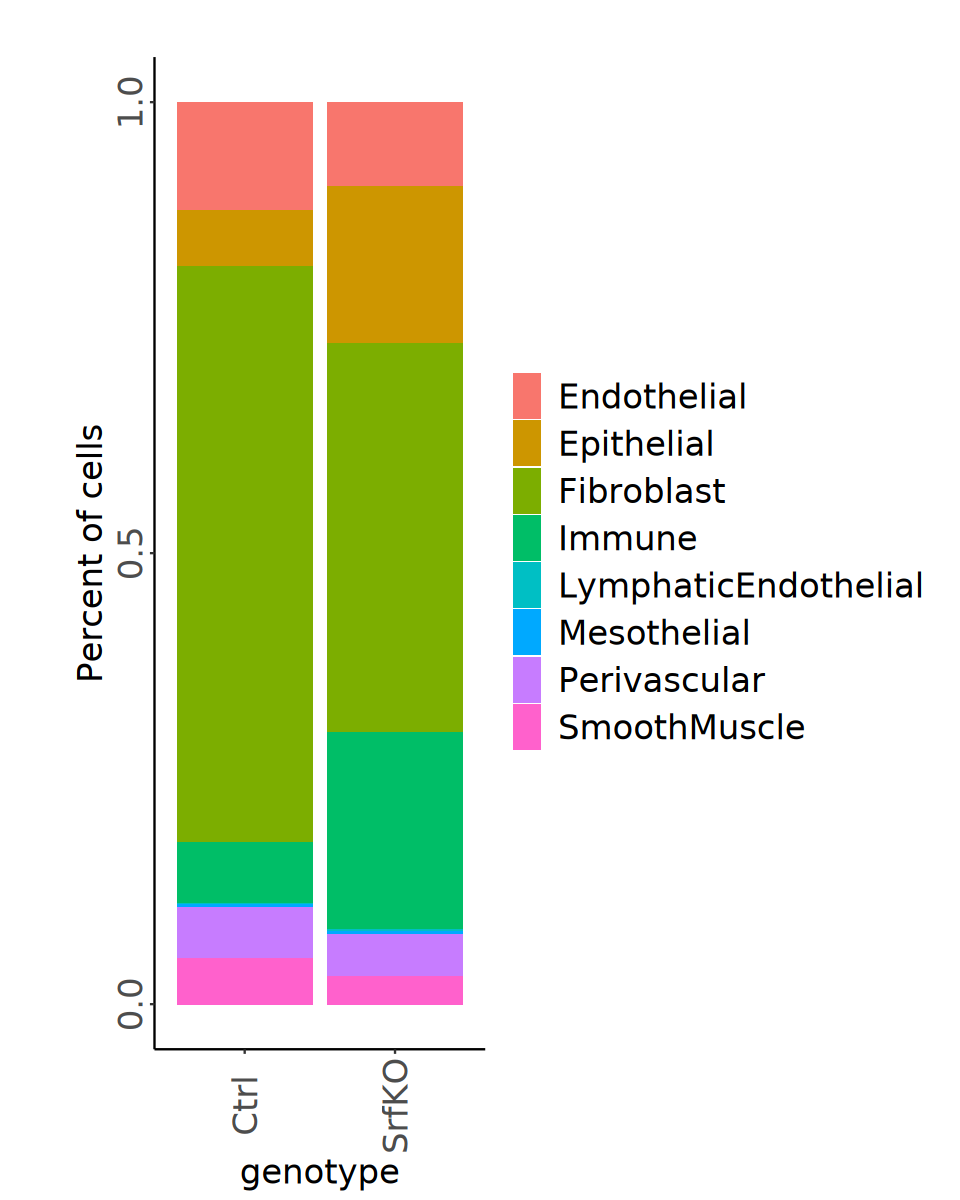

In [351]:
# Use DittoSeq to plot fraction of each broad cell type by genotype (Turn)

# first some prep work to extract the color pallette from the seurat object
require(scales)
Adult_Srfflox_SrfKO_tmp <- Adult_Srfflox_SrfKO
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$CellTypeBroad
# Create vector with levels of object@ident
identities <- levels(Adult_Srfflox_SrfKO_tmp)
# Create vector of default ggplot2 colors
my_color_palette <- hue_pal()(length(identities))
# Use dittoBarPlot to generate the plot with some customization

saved <- options(repr.plot.width = 8, repr.plot.height = 10) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "CellTypeBroad", 
             group.by = "genotype",
             color.panel = my_color_palette, 
             main = "") + theme(axis.text = element_text(size = 20, angle = 90),
                    axis.text.y = element_text(size = 20, angle = 90, vjust = 0.5, hjust=0.5),
                    axis.text.x = element_text(size = 20, angle = 90, vjust = 0.5, hjust=0.5),
                    title = element_text(size = 20, hjust = 0.5), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    aspect.ratio = 3/1)

options(saved) # restore old settings


In [152]:
# Count cells by type to compare between genotypes
cell_table <- table(Adult_Srfflox_SrfKO_tmp$CellTypeBroad, Adult_Srfflox_SrfKO_tmp$genotype)
cell_table

                      
                        Ctrl SrfKO
  Endothelial           2118  1492
  Epithelial            1080  2770
  Fibroblast           11243  6856
  Immune                1188  3467
  LymphaticEndothelial    21    31
  Mesothelial             67    60
  Perivascular          1001   735
  SmoothMuscle           883   488

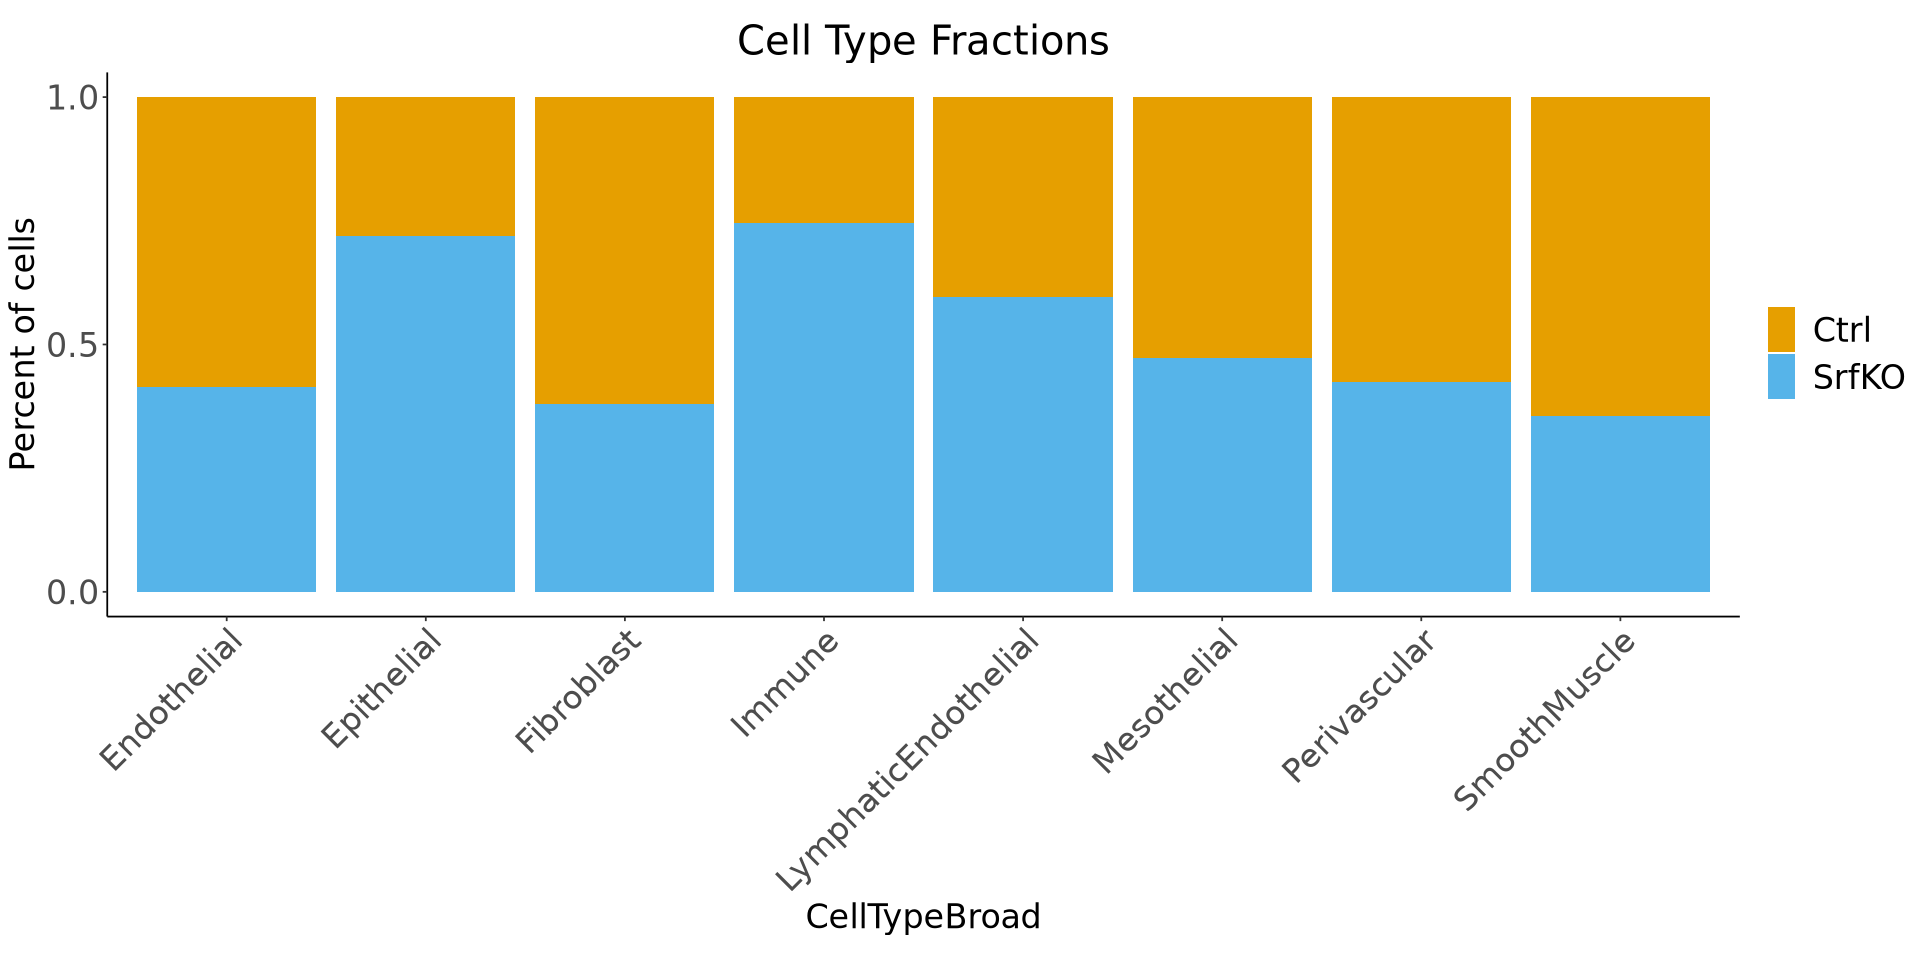

In [88]:
# Use DittoSeq to plot fraction of each cell type by genotype

saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "genotype", 
             group.by = "CellTypeBroad", 
             main = "Cell Type Fractions") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 1/3)

options(saved) # restore old settings

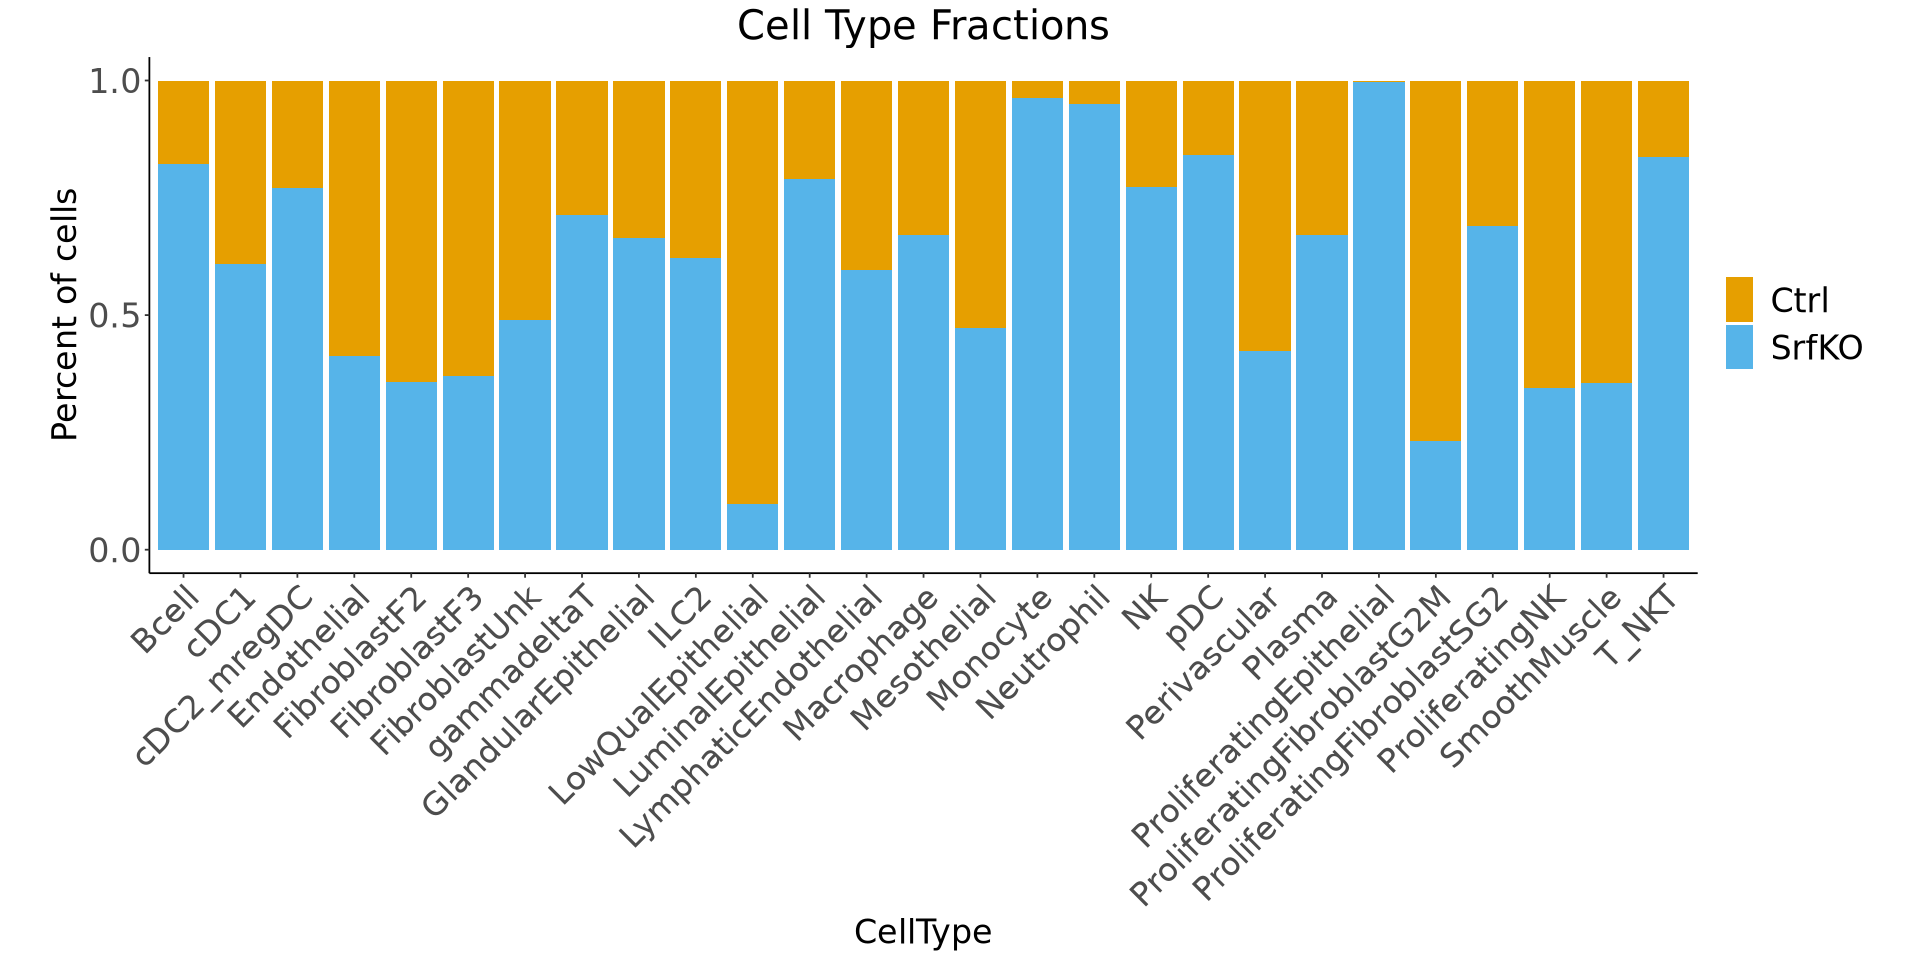

In [87]:
# Use DittoSeq to plot fraction of each cell type by genotype

saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "genotype", 
             group.by = "CellType", 
             main = "Cell Type Fractions") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 1/3)

options(saved) # restore old settings

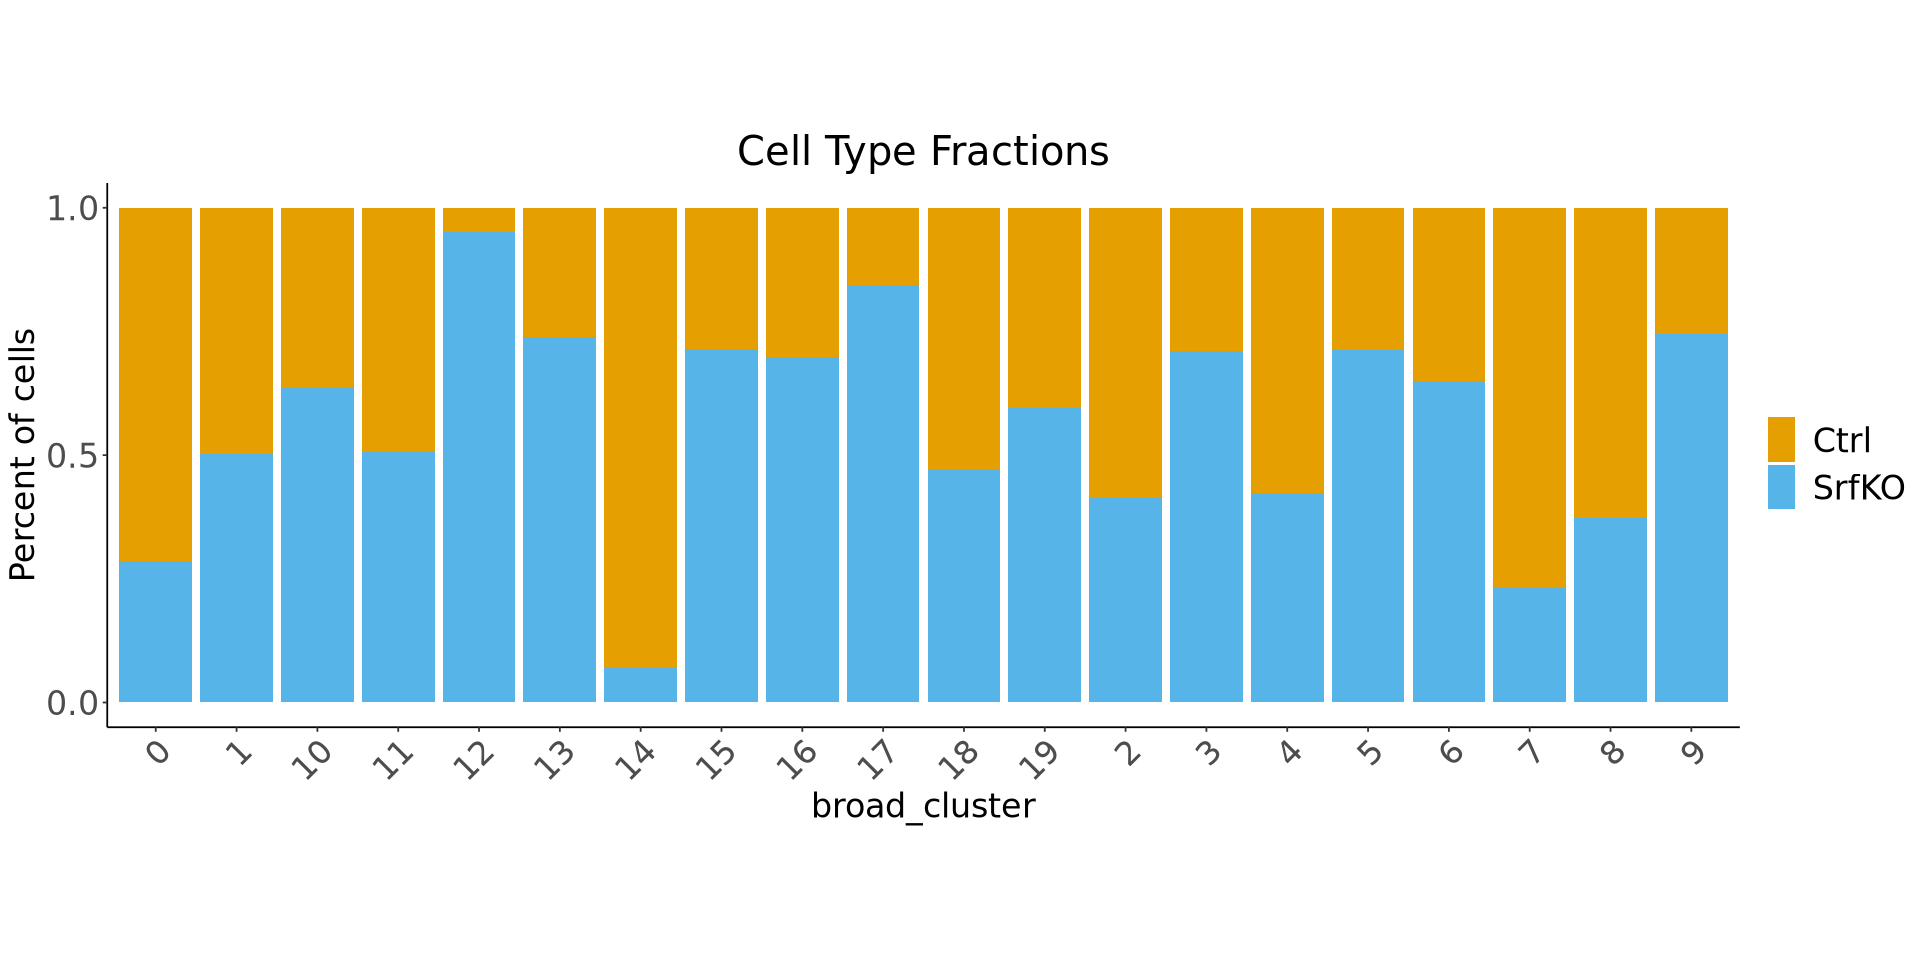

In [115]:
# Use DittoSeq to plot fraction of each cell type by genotype

saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "genotype", 
             group.by = "broad_cluster", 
             main = "Cell Type Fractions") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 1/3)

options(saved) # restore old settings

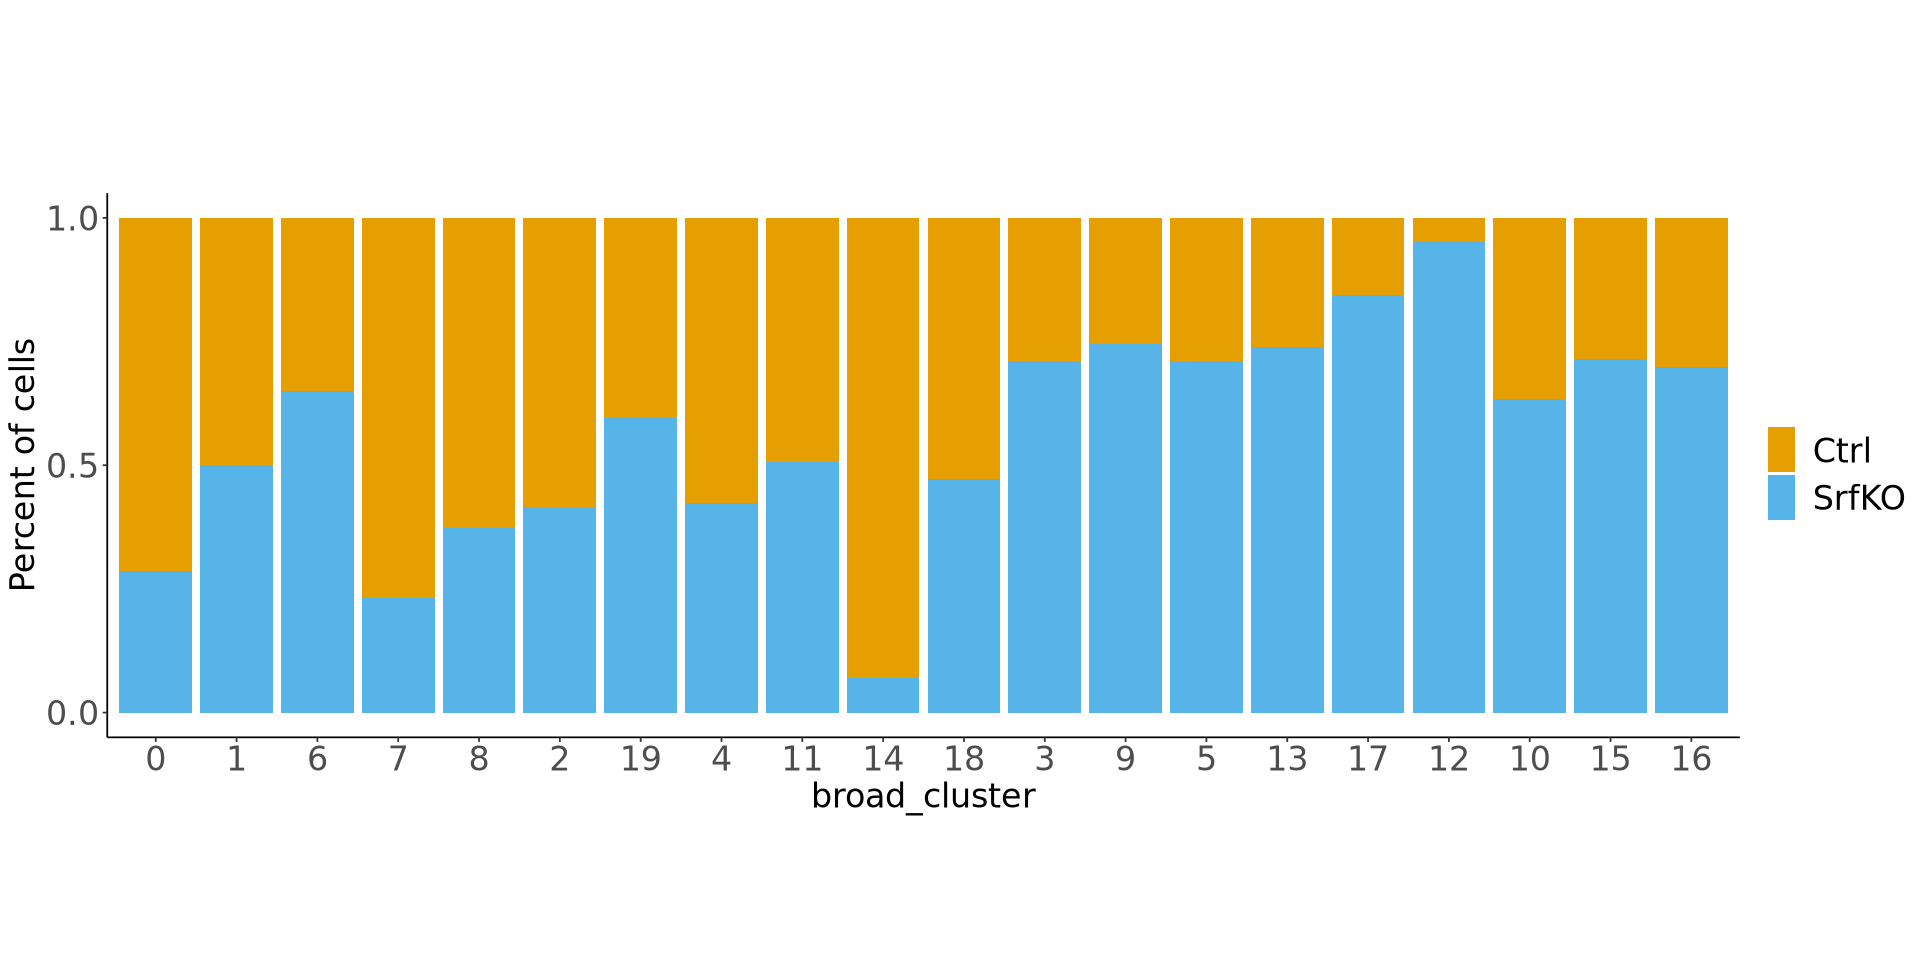

In [118]:
# Reorder, turn off label rotation, remove title
# Use DittoSeq to plot fraction of each cell type by genotype

saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

dittoBarPlot(Adult_Srfflox_SrfKO_tmp, 
             var = "genotype", 
             group.by = "broad_cluster",
             x.reorder = c(1, 2, 17, 18, 19, 13, 12, 15, 4, 7, 11, 14, 20, 16, 6, 10, 5, 3, 8, 9),
             x.labels.rotate = FALSE,
             main = "") + theme(axis.text = element_text(size = 20), 
                    legend.text = element_text(size = 20), 
                    legend.key.height = unit(1, 'cm'), 
                    title = element_text(size = 20, hjust = 0.5), 
                    plot.title = element_text(hjust=0.5), 
                    aspect.ratio = 1/3)

options(saved) # restore old settings



In [120]:
head(Adult_Srfflox_SrfKO_tmp)
tail(Adult_Srfflox_SrfKO_tmp)

,orig.ident,nCount_RNA,nFeature_RNA,Sample,genotype,batch,percent.mt,percent.rp,percent.hg,S.Score,G2M.Score,Phase,old.ident,CC.Difference,broad_cluster,CellType,CellSubtype,CellTypeBroad
,<chr>,<dbl>,<int>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<fct>,<chr>,<chr>,<chr>
Ctrl1___AAACCCAAGACCATAA-1,Ctrl1,13853,4097,Ctrl1,Ctrl,1,4.858153,21.86530,0,-0.115882733,-0.10197415,G1,Ctrl1,-0.01390858,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCAAGGTCCCGT-1,Ctrl1,5652,2163,Ctrl1,Ctrl,1,2.813163,11.34112,0,-0.087413046,-0.16113772,G1,Ctrl1,0.07372467,5,Macrophage,Macrophage,Immune
Ctrl1___AAACCCACATCACCAA-1,Ctrl1,6085,2336,Ctrl1,Ctrl,1,2.678718,10.56697,0,-0.070066492,-0.04961594,G1,Ctrl1,-0.02045055,15,gammadeltaT,gammadeltaT,Immune
Ctrl1___AAACCCACATCTAACG-1,Ctrl1,12378,3609,Ctrl1,Ctrl,1,3.869769,14.76006,0,-0.035871272,-0.09095433,G1,Ctrl1,0.05508306,11,SmoothMuscle,none,SmoothMuscle
Ctrl1___AAACCCACATGTCAGT-1,Ctrl1,15094,4189,Ctrl1,Ctrl,1,3.186697,23.22777,0,0.795792256,0.30071105,S,Ctrl1,0.49508121,10,ProliferatingNK,ProliferatingNK,Immune
Ctrl1___AAACCCAGTAATGTGA-1,Ctrl1,14440,4595,Ctrl1,Ctrl,1,4.903047,18.98199,0,0.056406385,0.58059310,G2M,Ctrl1,-0.52418671,7,ProliferatingFibroblastG2M,ProliferatingFibroblastG2M,Fibroblast
Ctrl1___AAACCCAGTGTAGGAC-1,Ctrl1,19929,4617,Ctrl1,Ctrl,1,5.996287,24.48191,0,-0.084860322,-0.12601747,G1,Ctrl1,0.04115715,3,GlandularEpithelial,GlandularEpithelial,Epithelial
Ctrl1___AAACCCATCGCCGAGT-1,Ctrl1,20720,5042,Ctrl1,Ctrl,1,4.917954,23.61004,0,-0.007086613,-0.04976484,G1,Ctrl1,0.04267823,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCATCGGCAGTC-1,Ctrl1,15461,4527,Ctrl1,Ctrl,1,4.359356,15.99508,0,0.559701893,0.82661813,G2M,Ctrl1,-0.26691623,2,Endothelial,none,Endothelial


,orig.ident,nCount_RNA,nFeature_RNA,Sample,genotype,batch,percent.mt,percent.rp,percent.hg,S.Score,G2M.Score,Phase,old.ident,CC.Difference,broad_cluster,CellType,CellSubtype,CellTypeBroad
,<chr>,<dbl>,<int>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<fct>,<chr>,<chr>,<chr>
SrfKO2___TTTGTTGCAGCGGTCT-1,SrfKO2,19483,5221,SrfKO2,SrfKO,2,4.178001,17.35872,0.000000000,-0.03144870,-0.136558824,G1,SrfKO2,0.105110125,11,SmoothMuscle,none,SmoothMuscle
SrfKO2___TTTGTTGCAGTCGGTC-1,SrfKO2,18492,4779,SrfKO2,SrfKO,2,6.527147,20.13844,0.000000000,-0.02638923,-0.066052893,G1,SrfKO2,0.039663658,4,Perivascular,none,Perivascular
SrfKO2___TTTGTTGCATGTGCCG-1,SrfKO2,14906,4540,SrfKO2,SrfKO,2,8.667651,13.98766,0.000000000,0.01955876,-0.132963045,S,SrfKO2,0.152521801,1,FibroblastF2,FibroblastF2,Fibroblast
SrfKO2___TTTGTTGGTATAGGAT-1,SrfKO2,4471,1718,SrfKO2,SrfKO,2,6.217848,26.12391,0.000000000,-0.01399089,-0.095814763,G1,SrfKO2,0.081823877,4,Perivascular,none,Perivascular
SrfKO2___TTTGTTGGTGTCATCA-1,SrfKO2,13706,3438,SrfKO2,SrfKO,2,2.021013,24.79936,0.000000000,0.02214257,-0.020580838,S,SrfKO2,0.042723406,13,cDC2_mregDC,cDC2_mregDC,Immune
SrfKO2___TTTGTTGGTTCCCACT-1,SrfKO2,46132,7522,SrfKO2,SrfKO,2,3.756611,18.53594,0.002167693,0.31618270,-0.023431350,S,SrfKO2,0.339614049,3,GlandularEpithelial,GlandularEpithelial,Epithelial
SrfKO2___TTTGTTGGTTTCGGCG-1,SrfKO2,42922,6825,SrfKO2,SrfKO,2,3.408508,24.78915,0.000000000,0.42673372,-0.009403705,S,SrfKO2,0.436137427,3,ProliferatingEpithelial,ProliferatingEpithelial,Epithelial
SrfKO2___TTTGTTGTCCGGGACT-1,SrfKO2,64090,8161,SrfKO2,SrfKO,2,2.746138,17.88579,0.001560306,0.20707582,1.093375748,G2M,SrfKO2,-0.886299932,3,ProliferatingEpithelial,ProliferatingEpithelial,Epithelial
SrfKO2___TTTGTTGTCGCTCCTA-1,SrfKO2,22533,5309,SrfKO2,SrfKO,2,3.994142,19.29614,0.000000000,-0.09602238,-0.118531639,G1,SrfKO2,0.022509254,1,FibroblastF2,FibroblastF2,Fibroblast


In [121]:
#Subset SrfKO only and Ctrl only
SrfKO_tmp <- subset(Adult_Srfflox_SrfKO_tmp, genotype == "SrfKO")

Ctrl_tmp <- subset(Adult_Srfflox_SrfKO_tmp, genotype == "Ctrl")

SrfKO_tmp
Ctrl_tmp


An object of class Seurat 
26486 features across 15899 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

An object of class Seurat 
26486 features across 17601 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

In [190]:
Idents(SrfKO_tmp) <- SrfKO_tmp$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = SrfKO_tmp, features = "Srf")
percent_stats

,Immune,Fibroblast,Endothelial,Perivascular,Epithelial,Mesothelial,SmoothMuscle,LymphaticEndothelial
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Srf,14.71012,1.662777,44.50402,7.891156,2.527076,33.33333,25.61475,25.80645


In [191]:
Idents(Ctrl_tmp) <- Ctrl_tmp$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Ctrl_tmp, features = "Srf")
percent_stats

,Fibroblast,Immune,SmoothMuscle,Epithelial,Endothelial,Perivascular,Mesothelial,LymphaticEndothelial
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Srf,29.84968,16.41414,54.02039,72.03704,39.70727,32.86713,22.38806,14.28571
